# Lista 3 - RNN, LSTM, GRU e Transformers
**Aluno:** Vitor Fontenele de Oliveira Linhares

**Mátricula:** 1700778

In [3]:

import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST, MNIST
from torchvision.utils import make_grid
from ucimlrepo import fetch_ucirepo
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import torch
from datasets import load_dataset
import pandas as pd


DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

Primeiras linhas (treino):


,label,title,description
0,Business,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,Business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...



Distribuicao por classe:


,label,train_count,test_count,train_pct,test_pct
0,World,30000,1900,25.0,25.0
1,Sports,30000,1900,25.0,25.0
2,Business,30000,1900,25.0,25.0
3,Sci/Tech,30000,1900,25.0,25.0



Estatisticas de tamanho (amostra treino):


,count,mean,std,min,25%,50%,75%,max
title_n_words,20000.0,6.7750,2.066758,1.0,5.0,7.0,8.0,17.0
description_n_words,20000.0,31.0154,9.819363,4.0,25.0,30.0,36.0,168.0


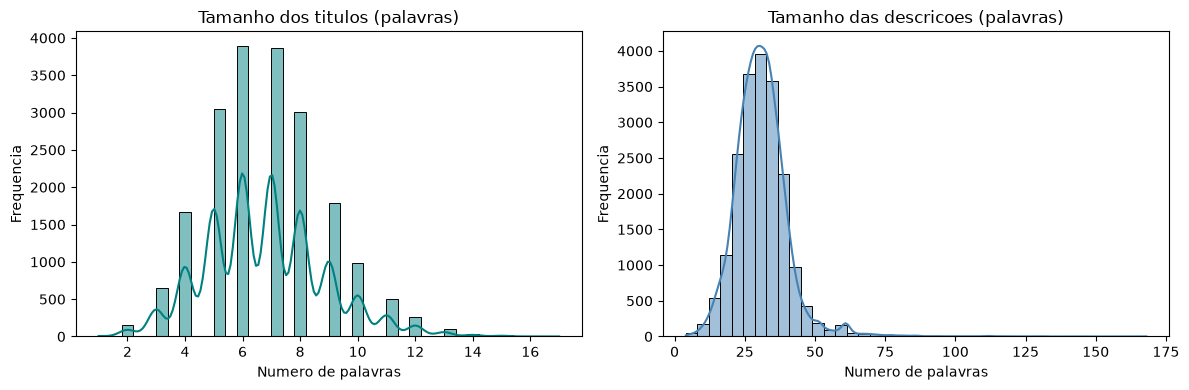


Exemplos de noticias por classe:


,label,title,description
0,Business,US house sales fall in July,Sales of non-new houses in the US fell last mo...
1,Business,DJ to acquire MarketWatch,"Dow Jones amp; Co., publisher of the Wall Str..."
2,Sci/Tech,Gartner optimistic about chip numbers,But that optimism isn #39;t matched by Infineo...
3,Sci/Tech,Fossil Indicates Brown Bears Went South,"CALGARY, Alberta - A fossilized jaw found in a..."
4,Sports,Second Andre win in a row boosts US gold medal...,"Andre Dirrell, fighting with a tattoo of his g..."
5,Sports,NFL Game Summary - Kansas City at New Orleans,Tight end Tony Gonzalez caught six passes for ...
6,World,Explosion Rocks Baghdad Neighborhood,"BAGHDAD, Iraq, August 24 -- A car bomb explode..."
7,World,BBC reporters' log,BBC correspondents record events in the Middle...


Resumo: AG News e um problema de classificacao supervisionada multiclasse (4 classes). Para o proximo passo (RNN), podemos escolher usar title, description, ou a concatenacao dos dois.


In [ ]:
ds = load_dataset("sh0416/ag_news")

print(ds)

df_train_raw = pd.DataFrame(ds["train"])
df_test_raw = pd.DataFrame(ds["test"])

id2label = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

def normalize_label_to_one_based(label_series):
    unique_vals = set(label_series.unique())
    if unique_vals.issubset({1, 2, 3, 4}):
        return label_series.astype(int)
    if unique_vals.issubset({0, 1, 2, 3}):
        return (label_series.astype(int) + 1)
    raise ValueError(f"Labels fora do esperado: {sorted(unique_vals)}")

def build_exploration_df(df_raw):
    needed_cols = {"label", "title", "description"}
    if not needed_cols.issubset(df_raw.columns):
        raise ValueError("Dataset nao possui as colunas esperadas: label, title e description.")

    df = df_raw[["label", "title", "description"]].copy()
    df["label_id"] = normalize_label_to_one_based(df["label"])
    df["label"] = df["label_id"].map(id2label)
    df = df[["label", "title", "description", "label_id"]]
    return df

df_train = build_exploration_df(df_train_raw)
df_test = build_exploration_df(df_test_raw)

print("\nPrimeiras linhas (treino):")
display(df_train[["label", "title", "description"]].head(3))

train_counts = df_train["label"].value_counts().reindex(["World", "Sports", "Business", "Sci/Tech"], fill_value=0)
test_counts = df_test["label"].value_counts().reindex(["World", "Sports", "Business", "Sci/Tech"], fill_value=0)

dist_df = pd.DataFrame({
    "label": train_counts.index,
    "train_count": train_counts.values,
    "test_count": test_counts.values,
})
dist_df["train_pct"] = (dist_df["train_count"] / len(df_train) * 100).round(2)
dist_df["test_pct"] = (dist_df["test_count"] / len(df_test) * 100).round(2)

print("\nDistribuicao por classe:")
display(dist_df)

sample_df = df_train.sample(n=min(20000, len(df_train)), random_state=42).copy()
sample_df["title_n_words"] = sample_df["title"].astype(str).str.split().str.len()
sample_df["description_n_words"] = sample_df["description"].astype(str).str.split().str.len()

print("\nEstatisticas de tamanho (amostra treino):")
display(sample_df[["title_n_words", "description_n_words"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(sample_df["title_n_words"], bins=40, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Tamanho dos titulos")
axes[0].set_xlabel("Numero de palavras")
axes[0].set_ylabel("Frequencia")

sns.histplot(sample_df["description_n_words"], bins=40, kde=True, color="steelblue", ax=axes[1])
axes[1].set_title("Tamanho das descricoes")
axes[1].set_xlabel("Numero de palavras")
axes[1].set_ylabel("Frequencia")

plt.tight_layout()
plt.show()

example_parts = []
for label_name in ["World", "Sports", "Business", "Sci/Tech"]:
    class_df = df_train[df_train["label"] == label_name]
    class_sample = class_df.sample(n=min(2, len(class_df)), random_state=42)
    example_parts.append(class_sample)

examples = pd.concat(example_parts, ignore_index=True).sort_values("label").reset_index(drop=True)

print("\nExemplos de noticias por classe:")
display(examples[["label", "title", "description"]])

print(
    "Resumo: AG News e um problema de classificacao supervisionada multiclasse (4 classes). "
    "Para o proximo passo (RNN), podemos escolher usar title, description, ou a concatenacao dos dois."
)